# FEVER Multi-Agent Consensus — Results Analysis

Analysis of `ferver_mas_consensus_results.jsonl`: a 4-agent LLM multi-agent
system (MAS) verifying FEVER claims (`SUPPORTS` / `REFUTES` / `NOT_ENOUGH_INFO`).

**MAS voting rule** (see `ferver_mas_consensus.py`): each of the 4 agents casts
an independent verdict in round 0. If **>= 3 of 4 agents already agree**
(Byzantine-style quorum, tolerating `f=1` unreliable vote for `n=4 >= 3f+1`),
that verdict is finalized immediately (`rounds_run = 0`). Otherwise the agents
enter deliberation rounds, sharing a moderator recap of everyone's
label/confidence/reasoning and revoting, until quorum forms or `max_rounds`
is exhausted (a persistent 2-2 split falls back to `NOT_ENOUGH_INFO`).

> **Note:** `ferver_mas_consensus_results.jsonl` is the live output of an
> ongoing evaluation run and grows as new claims finish, so the exact counts
> below reflect a snapshot at the time this notebook was last executed
> (re-run all cells to refresh against the latest file).

This notebook covers:
1. Dataset overview
2. Correct vs incorrect verdicts
3. Ground truth vs MAS system label distribution
4. Confusion matrix
5. Per-class accuracy
6. Distribution of consensus rounds
7. Accuracy vs number of consensus rounds
8. Vote unanimity (4-0 vs 3-1) and its relation to accuracy
9. Error analysis

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#888888",
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

LABELS = ["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO"]
LABEL_TITLE = {l: l.replace("_", " ").title() for l in LABELS}

# Okabe-Ito colorblind-safe palette, assigned by fixed order / by job.
CLASS_COLOR = {
    "SUPPORTS": "#0072B2",         # blue
    "REFUTES": "#D55E00",          # vermillion
    "NOT_ENOUGH_INFO": "#E69F00",  # orange
}
STATUS_COLOR = {"Correct": "#009E73", "Incorrect": "#D55E00"}   # bluish green / vermillion
SOURCE_COLOR = {"Ground Truth": "#0072B2", "MAS System": "#E69F00"}
SPLIT_COLOR = {"Unanimous (4-0)": "#0072B2", "Split (3-1)": "#CC79A7"}


def annotate_bars(ax, bars, fmt="{:,.0f}", pad_frac=0.015):
    ymax = ax.get_ylim()[1]
    pad = ymax * pad_frac
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + pad, fmt.format(h),
                 ha="center", va="bottom", fontsize=9, color="#333333")

In [2]:
DATA_PATH = Path("ferver_mas_consensus_results.jsonl")
records = [json.loads(line) for line in DATA_PATH.open()]
df = pd.DataFrame(records)

df["n_votes"] = df["final_tally"].apply(lambda t: sum(t.values()))
df["unanimous"] = df["final_tally"].apply(lambda t: len(t) == 1)
df["consensus_type"] = np.where(df["unanimous"], "Unanimous (4-0)", "Split (3-1)")
df["outcome"] = np.where(df["correct"], "Correct", "Incorrect")

print(f"Loaded {len(df):,} claims from {DATA_PATH}")
df.head(3)

Loaded 16,906 claims from ferver_mas_consensus_results.jsonl


,claim,evidence,ground_truth_label,final_label,final_output,rounds_run,final_tally,correct,n_votes,unanimous,consensus_type,outcome
0,Colin Kaepernick became a starting quarterback...,,NOT_ENOUGH_INFO,NOT_ENOUGH_INFO,Not enough info,0,{'NOT_ENOUGH_INFO': 4},True,4,True,Unanimous (4-0),Correct
1,Tilda Swinton is a vegan.,,NOT_ENOUGH_INFO,NOT_ENOUGH_INFO,Not enough info,0,{'NOT_ENOUGH_INFO': 4},True,4,True,Unanimous (4-0),Correct
2,Fox 2000 Pictures released the film Soul Food.,Soul Food is a 1997 American comedy-drama film...,SUPPORTS,SUPPORTS,True,0,{'SUPPORTS': 4},True,4,True,Unanimous (4-0),Correct


## 1. Dataset Overview

In [3]:
overview = pd.Series({
    "Total claims": len(df),
    "Correct": int(df["correct"].sum()),
    "Incorrect": int((~df["correct"]).sum()),
    "Resolved in round 0 (no deliberation)": int((df["rounds_run"] == 0).sum()),
    "Required >=1 deliberation round": int((df["rounds_run"] > 0).sum()),
    "Unanimous 4-0 votes": int(df["unanimous"].sum()),
    "Split 3-1 votes": int((~df["unanimous"]).sum()),
}, name="count").to_frame()
overview["pct"] = (overview["count"] / len(df) * 100).round(2)
overview

,count,pct
Total claims,16906,100.00
Correct,15994,94.61
Incorrect,912,5.39
Resolved in round 0 (no deliberation),16633,98.39
Required >=1 deliberation round,273,1.61
Unanimous 4-0 votes,15987,94.56
Split 3-1 votes,919,5.44


## 2. Correct vs Incorrect Verdicts

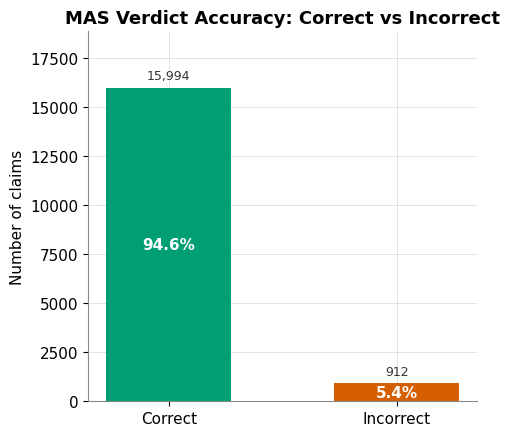

Overall accuracy: 94.61% (15,994 / 16,906)


In [4]:
counts = df["outcome"].value_counts().reindex(["Correct", "Incorrect"])

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(counts.index, counts.values,
              color=[STATUS_COLOR[c] for c in counts.index], width=0.55)
ax.set_ylim(0, counts.max() * 1.18)
annotate_bars(ax, bars)
for b, v in zip(bars, counts.values):
    pct = v / counts.sum() * 100
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() * 0.5, f"{pct:.1f}%",
            ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of claims")
ax.set_title("MAS Verdict Accuracy: Correct vs Incorrect")
plt.tight_layout()
plt.show()

print(f"Overall accuracy: {counts['Correct'] / counts.sum():.2%} "
      f"({counts['Correct']:,} / {counts.sum():,})")

## 3. Label Distribution: Ground Truth vs MAS System Verdict

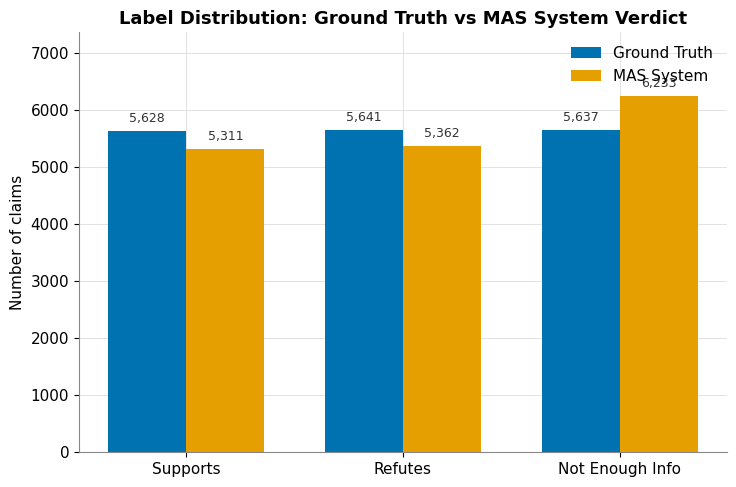

In [5]:
gt_counts = df["ground_truth_label"].value_counts().reindex(LABELS)
pred_counts = df["final_label"].value_counts().reindex(LABELS)

x = np.arange(len(LABELS))
width = 0.36
fig, ax = plt.subplots(figsize=(7.5, 5))
b1 = ax.bar(x - width / 2, gt_counts.values, width,
            label="Ground Truth", color=SOURCE_COLOR["Ground Truth"])
b2 = ax.bar(x + width / 2, pred_counts.values, width,
            label="MAS System", color=SOURCE_COLOR["MAS System"])
ax.set_ylim(0, max(gt_counts.max(), pred_counts.max()) * 1.18)
annotate_bars(ax, b1)
annotate_bars(ax, b2)
ax.set_xticks(x)
ax.set_xticklabels([LABEL_TITLE[l] for l in LABELS])
ax.set_ylabel("Number of claims")
ax.set_title("Label Distribution: Ground Truth vs MAS System Verdict")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Confusion Matrix

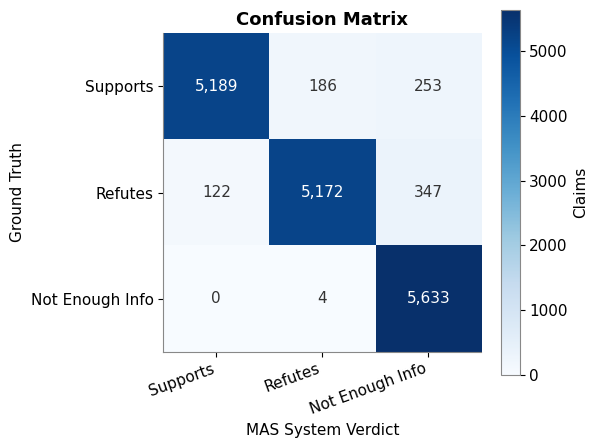

,precision,recall,f1-score,support
SUPPORTS,0.977,0.922,0.949,5628.000
REFUTES,0.965,0.917,0.940,5641.000
NOT_ENOUGH_INFO,0.904,0.999,0.949,5637.000
accuracy,0.946,0.946,0.946,0.946
macro avg,0.948,0.946,0.946,16906.000
weighted avg,0.948,0.946,0.946,16906.000


In [6]:
cm = confusion_matrix(df["ground_truth_label"], df["final_label"], labels=LABELS)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels([LABEL_TITLE[l] for l in LABELS], rotation=20, ha="right")
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels([LABEL_TITLE[l] for l in LABELS])
ax.set_xlabel("MAS System Verdict")
ax.set_ylabel("Ground Truth")
ax.set_title("Confusion Matrix")
ax.grid(False)
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > thresh else "#333333")
fig.colorbar(im, ax=ax, shrink=0.8, label="Claims")
plt.tight_layout()
plt.show()

report = classification_report(df["ground_truth_label"], df["final_label"],
                                labels=LABELS, output_dict=True)
pd.DataFrame(report).T.round(3)

## 5. Per-Class Accuracy

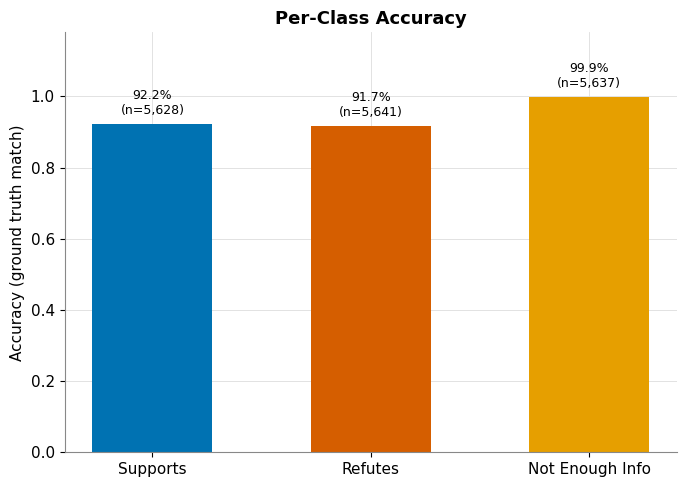

In [7]:
acc_by_class = df.groupby("ground_truth_label")["correct"].mean().reindex(LABELS)
n_by_class = df.groupby("ground_truth_label").size().reindex(LABELS)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar([LABEL_TITLE[l] for l in LABELS], acc_by_class.values,
              color=[CLASS_COLOR[l] for l in LABELS], width=0.55)
ax.set_ylim(0, 1.18)
for b, n in zip(bars, n_by_class.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f"{b.get_height():.1%}\n(n={n:,})", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Accuracy (ground truth match)")
ax.set_title("Per-Class Accuracy")
plt.tight_layout()
plt.show()

## 6. Distribution of Consensus Rounds

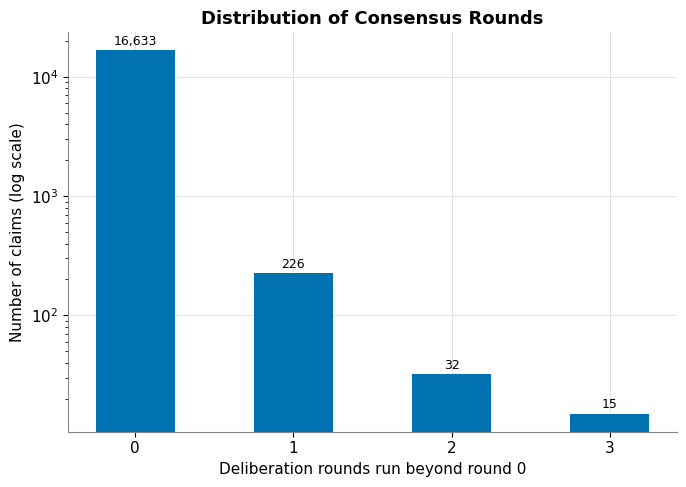

,count,pct
rounds_run,,
0,16633,98.39
1,226,1.34
2,32,0.19
3,15,0.09


In [8]:
rounds_counts = df["rounds_run"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(rounds_counts.index.astype(str), rounds_counts.values,
              color=SOURCE_COLOR["Ground Truth"], width=0.5)
ax.set_yscale("log")
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h * 1.05, f"{h:,}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Deliberation rounds run beyond round 0")
ax.set_ylabel("Number of claims (log scale)")
ax.set_title("Distribution of Consensus Rounds")
plt.tight_layout()
plt.show()

rounds_counts.to_frame("count").assign(pct=lambda d: (d["count"] / len(df) * 100).round(2))

## 7. Accuracy vs Number of Consensus Rounds

The vast majority of claims (>98%) reach quorum in round 0. The few that
require deliberation are, almost by definition, the ones where the 4 agents
initially disagreed — and the chart below shows accuracy drops sharply for
those. Sample sizes for `rounds_run >= 1` are small (tens of claims), so
treat those bars as directional rather than statistically strong.

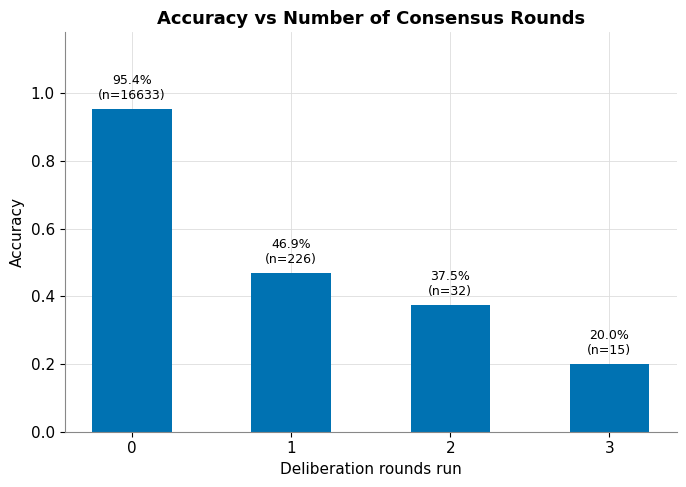

,accuracy,n
rounds_run,,
0,0.954308,16633
1,0.469027,226
2,0.375000,32
3,0.200000,15


In [9]:
acc_by_round = df.groupby("rounds_run")["correct"].agg(["mean", "size"]) \
                 .rename(columns={"mean": "accuracy", "size": "n"})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(acc_by_round.index.astype(str), acc_by_round["accuracy"],
              color="#0072B2", width=0.5)
ax.set_ylim(0, 1.18)
for b, n in zip(bars, acc_by_round["n"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f"{b.get_height():.1%}\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Deliberation rounds run")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Number of Consensus Rounds")
plt.tight_layout()
plt.show()

acc_by_round

## 8. Vote Unanimity (4-0 vs 3-1) and Accuracy

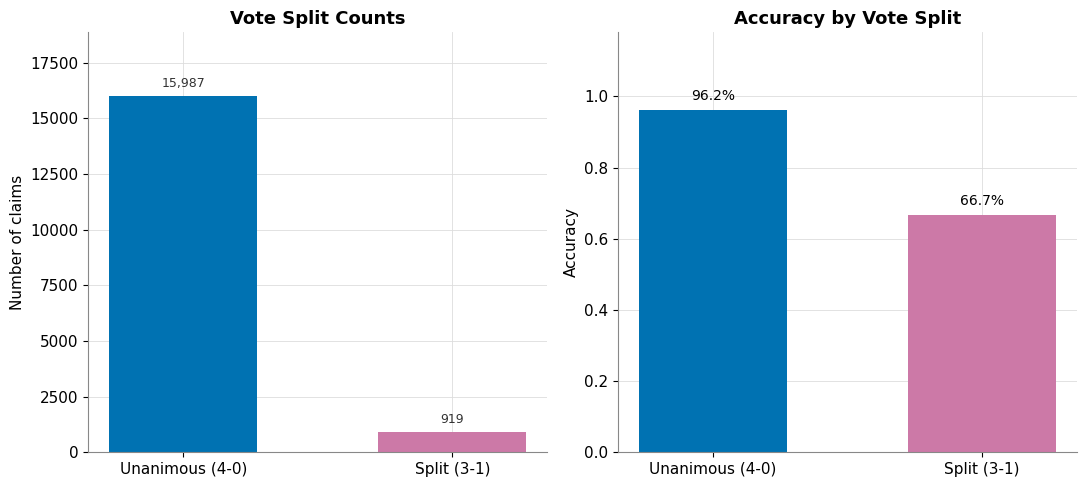

In [10]:
cons_counts = df["consensus_type"].value_counts().reindex(["Unanimous (4-0)", "Split (3-1)"])
cons_acc = df.groupby("consensus_type")["correct"].mean().reindex(["Unanimous (4-0)", "Split (3-1)"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

bars0 = axes[0].bar(cons_counts.index, cons_counts.values,
                     color=[SPLIT_COLOR[c] for c in cons_counts.index], width=0.55)
axes[0].set_ylim(0, cons_counts.max() * 1.18)
annotate_bars(axes[0], bars0)
axes[0].set_title("Vote Split Counts")
axes[0].set_ylabel("Number of claims")

bars1 = axes[1].bar(cons_acc.index, cons_acc.values,
                     color=[SPLIT_COLOR[c] for c in cons_acc.index], width=0.55)
axes[1].set_ylim(0, 1.18)
for b in bars1:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
                 f"{b.get_height():.1%}", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Accuracy by Vote Split")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## 9. Error Analysis

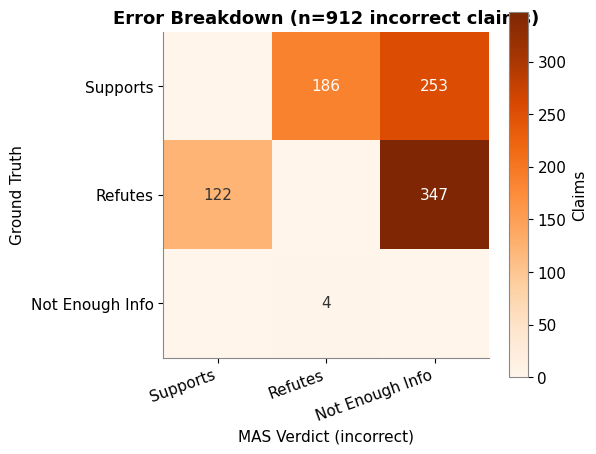

In [11]:
errors = df[~df["correct"]]
err_ct = pd.crosstab(errors["ground_truth_label"], errors["final_label"]) \
           .reindex(index=LABELS, columns=LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(err_ct.values, cmap="Oranges")
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels([LABEL_TITLE[l] for l in LABELS], rotation=20, ha="right")
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels([LABEL_TITLE[l] for l in LABELS])
ax.set_xlabel("MAS Verdict (incorrect)")
ax.set_ylabel("Ground Truth")
ax.set_title(f"Error Breakdown (n={len(errors):,} incorrect claims)")
ax.grid(False)
vmax = err_ct.values.max()
for i in range(err_ct.shape[0]):
    for j in range(err_ct.shape[1]):
        v = err_ct.values[i, j]
        if v:
            ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=11,
                    color="white" if v > vmax / 2 else "#333333")
fig.colorbar(im, ax=ax, shrink=0.8, label="Claims")
plt.tight_layout()
plt.show()

In [12]:
# A handful of example errors for qualitative inspection
errors[["claim", "ground_truth_label", "final_label", "rounds_run"]].sample(
    min(5, len(errors)), random_state=42
)

,claim,ground_truth_label,final_label,rounds_run
11923,Dev Patel has not worked with Neill Blomkamp.,SUPPORTS,REFUTES,0
14174,Skopje was a main city from 972 and 992.,REFUTES,SUPPORTS,0
10137,Doug Petrie made a cameo in Dr. Horrible's Sin...,SUPPORTS,NOT_ENOUGH_INFO,1
6671,Birthday Song (2 Chainz song) was produced by ...,REFUTES,SUPPORTS,0
6594,The Godfather Part II was snubbed at the BAFTA...,REFUTES,NOT_ENOUGH_INFO,1


## Key Findings

In [13]:
total = len(df)
n_correct = int(df["correct"].sum())
n_incorrect = total - n_correct
acc = n_correct / total

best_class = acc_by_class.idxmax()
worst_class = acc_by_class.idxmin()

round0_acc = acc_by_round.loc[0, "accuracy"] if 0 in acc_by_round.index else float("nan")
multi_round_mask = df["rounds_run"] > 0
multi_round_acc = df.loc[multi_round_mask, "correct"].mean()
n_multi_round = int(multi_round_mask.sum())

unanimous_acc = cons_acc.get("Unanimous (4-0)", float("nan"))
split_acc = cons_acc.get("Split (3-1)", float("nan"))

print("KEY FINDINGS")
print("=" * 64)
print(f"- Overall accuracy: {acc:.2%} ({n_correct:,}/{total:,} correct, {n_incorrect:,} incorrect)")
print(f"- Best-performing class:  {best_class:<16} accuracy {acc_by_class[best_class]:.2%}")
print(f"- Worst-performing class: {worst_class:<16} accuracy {acc_by_class[worst_class]:.2%}")
print(f"- {(df['rounds_run'] == 0).mean():.1%} of claims reached quorum in round 0 (no deliberation)")
print(f"- Round-0 accuracy: {round0_acc:.2%}  vs.  accuracy after >=1 deliberation round: "
      f"{multi_round_acc:.2%} (n={n_multi_round:,})")
print(f"- Unanimous 4-0 votes: {df['unanimous'].mean():.1%} of claims, accuracy {unanimous_acc:.2%}")
print(f"- Split 3-1 votes:     {(~df['unanimous']).mean():.1%} of claims, accuracy {split_acc:.2%}")

KEY FINDINGS
- Overall accuracy: 94.61% (15,994/16,906 correct, 912 incorrect)
- Best-performing class:  NOT_ENOUGH_INFO  accuracy 99.93%
- Worst-performing class: REFUTES          accuracy 91.69%
- 98.4% of claims reached quorum in round 0 (no deliberation)
- Round-0 accuracy: 95.43%  vs.  accuracy after >=1 deliberation round: 44.32% (n=273)
- Unanimous 4-0 votes: 94.6% of claims, accuracy 96.21%
- Split 3-1 votes:     5.4% of claims, accuracy 66.70%


**Takeaways**

- Round-0 quorum (>= 3/4 independent agents agreeing immediately) is both
  the overwhelming majority case and by far the more accurate one — needing
  deliberation rounds is a strong signal the claim was hard, and correlates
  with much lower accuracy on this sample.
- Similarly, unanimous 4-0 votes are markedly more reliable than 3-1 splits,
  suggesting vote margin/tally could be used as a confidence signal (e.g. to
  flag low-confidence verdicts for human review or an escalation path).
- `NOT_ENOUGH_INFO` claims and the round-0 / unanimous-vote cases are where
  the current 4-agent, quorum-based MAS is strongest; disagreement among
  agents is the leading indicator of an eventual error.